In [211]:
import sys
sys.path.insert(0, '/home/jonathan/Documents/mi3-gs/build/python')
sys.path.append("..")

import drjit as dr
import mitsuba as mi
mi.set_variant('cuda_ad_rgb')

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [212]:
import volprim
from volprim.integrators.common import *

In [213]:
from scripts.radiosity.radiance_cache import RadianceCache
from scripts.radiosity.surface_sampler import SceneSurfaceSampler
from scripts.radiosity.vertex_bsdf import Diffuse, Principled

# scene_path = "/home/jonathan/Documents/volprim-balance/scenes/mitsuba/matpreview_texture/matpreview.xml"
# scene = mi.load_file(scene_path)
# gs_path = "/home/jonathan/Documents/taming-3dgs/output/matpreview_texture/point_cloud/iteration_7000/point_cloud.ply"

scene_path = "/home/jonathan/Documents/volprim-balance/scenes/mitsuba/matpreview_default/matpreview.xml"
scene = mi.load_file(scene_path)
gs_path = "/home/jonathan/Documents/taming-3dgs/output/matpreview_default/point_cloud/iteration_7000/point_cloud.ply"

# scene_path = "/home/jonathan/Documents/volprim-balance/scenes/mitsuba/matpreview_specular/matpreview.xml"
# scene = mi.load_file(scene_path)
# gs_path = "/home/jonathan/Documents/taming-3dgs/output/matpreview_specular/point_cloud/iteration_7000/point_cloud.ply"

mesh_indices = [2]

if mesh_indices is None:
    mesh_indices = [i for i in range(len(scene.shapes()))]

radiance_cache = RadianceCache(scene, gs_path)
scene_sampler = SceneSurfaceSampler(scene, mesh_indexes=mesh_indices)
# bsdf_train = Diffuse()
bsdf_train = Principled()

In [214]:
for mesh_idx, mesh in enumerate(scene.shapes()):
    if not(mesh.shape_type() == mi.ShapeType.Mesh):
        continue

    if mesh_idx not in mesh_indices:
        continue
    # bsdf_train.initialize_mesh_attributes(mesh, [0.5, 0.5, 0.5]) # Diffuse
    bsdf_train.initialize_mesh_attributes(mesh, [0.5, 0.5, 0.5], 0.8, 0.0) # Principled

In [215]:
from scripts.radiosity.radiance_cache import _compute_loss_mis_RT_onesample
from scripts.radiosity.bsdf_utils import render_base_color, render_attributes
# from scripts.radiosity.regularizer import TVRegularizer
from scripts.largesteps_generic import LargeSteps
from time import time
import os

NUM_GEO_SAMPLES = 1 << 15

mesh_names = [mesh.id() for mesh_idx, mesh in enumerate(scene.shapes()) if mesh_idx in mesh_indices]
mesh_name = mesh_names[0]

params = mi.traverse(scene)
opt = mi.ad.Adam(lr=0.05, mask_updates=True)
keys = bsdf_train.register_params(opt, params)
lambda_ = 0.4
ls = LargeSteps(params[f'{mesh_name}.vertex_positions'], params[f'{mesh_name}.faces'], lambda_)
# reg = TVRegularizer(scene)

lr_dict = {}
for key in keys:
    opt_key = f'{key}_u'
    if "base_color" in key:
        opt[opt_key] = ls.to_differential_3(params[key])
    else:
        opt[opt_key] = ls.to_differential_1(params[key])

opt.set_learning_rate(lr_dict)

In [216]:
from scripts.restir.reservoir import MultiReservoirVector3f

losses = []

max_iterations = 100
spp = 64
Nf = dr.gather(mi.MeshPtr, scene.shapes_dr(), mesh_indices).face_count()[0]
num_slots = 4
rsv = MultiReservoirVector3f(Nf, num_slots)

fp = f"output/matpreview_texture/onesample_RT_samples={NUM_GEO_SAMPLES}/"
try:
    os.mkdir(fp)
except:
    pass

for it in range(max_iterations):
    if it % 50 == 0:
        render_base_color(scene, None, True, fp + f"itr={it}")

    if it % 250 == 0:
        render_attributes(scene, None, True, fp + f"itr={it}_attr")


    time1 = time()

    for key in keys:
        # Retrieve the per-vertex data from the latent variable
        if "base_color" in key:
            params[key] = ls.from_differential_3(opt[f'{key}_u'])
        else:
            params[key] = ls.from_differential_1(opt[f'{key}_u'])
    
        # Post-process the optimized parameters to ensure legal color values.
        if "roughness" in key:
            params[key] = dr.clip(params[key], 0.1, 1.0)
        else:
            params[key] = dr.clip(params[key], 0.0, 1.0)
        params.update()


    # # Evaluate the objective function for the current BSDF params
    loss = _compute_loss_mis_RT_onesample(scene_sampler, radiance_cache, bsdf_train, 
        NUM_GEO_SAMPLES, rng_state = it, spp=spp)

    # # Add regularization
    # loss += TV_coeff * reg.compute_loss(scene, ["vertex_bsdf_base_color", "vertex_bsdf_roughness"])

    # Backpropagate through the rendering process
    dr.backward(loss)

    # Optimizer: take a gradient descent step
    opt.step()

    # Post-process the optimized parameters to ensure legal color values.
    for key in keys:
        opt[key] = dr.clip(opt[key], 0.0, 1.0)

    if it in (int(0.7 * max_iterations), int(0.9 * max_iterations)):
        opt.set_learning_rate(0.5 * opt.lr['vertex_bsdf_base_color'])
        spp *= 2
        NUM_GEO_SAMPLES *= 2
        
    losses.append(loss.numpy())
    time2 = time()
    print(f"Iteration {1+it:03d} [{time2 - time1:2f}]: Loss = {loss}")

Iteration 001 [0.073932]: Loss = [5.8435]
Iteration 002 [0.063170]: Loss = [4.85347]
Iteration 003 [0.062131]: Loss = [4.00285]
Iteration 004 [0.061402]: Loss = [3.25188]
Iteration 005 [0.063647]: Loss = [2.60426]
Iteration 006 [0.063004]: Loss = [2.193]
Iteration 007 [0.061974]: Loss = [1.90619]
Iteration 008 [0.060959]: Loss = [1.41806]
Iteration 009 [0.063290]: Loss = [1.19027]
Iteration 010 [0.062877]: Loss = [1.07406]
Iteration 011 [0.062298]: Loss = [0.953334]
Iteration 012 [0.061203]: Loss = [0.897367]
Iteration 013 [0.063026]: Loss = [0.903882]
Iteration 014 [0.063385]: Loss = [0.863369]
Iteration 015 [0.063658]: Loss = [0.89321]
Iteration 016 [0.062157]: Loss = [0.858712]
Iteration 017 [0.062005]: Loss = [0.864002]
Iteration 018 [0.064088]: Loss = [0.842466]
Iteration 019 [0.063441]: Loss = [0.851773]
Iteration 020 [0.062721]: Loss = [0.859775]
Iteration 021 [0.061616]: Loss = [0.846883]
Iteration 022 [0.062998]: Loss = [0.828228]
Iteration 023 [0.064846]: Loss = [0.831753]
It

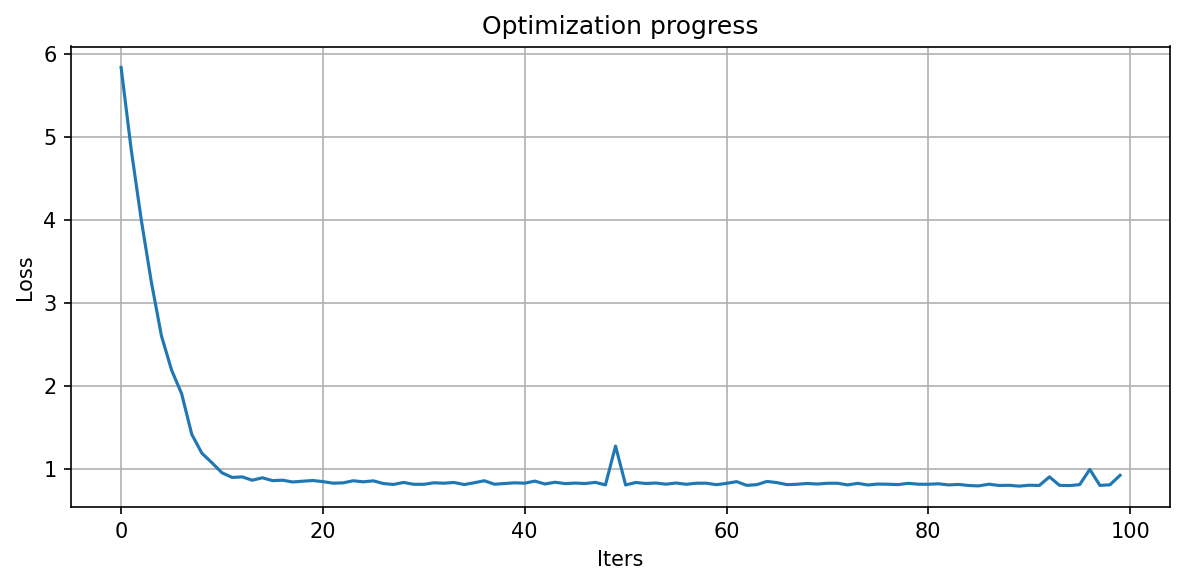

In [217]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4), dpi=150)
plt.title("Optimization progress")
plt.plot(np.array(losses))
plt.xlabel("Iters")
plt.ylabel("Loss")
plt.grid()
plt.tight_layout()
plt.savefig(fp + "loss.png")

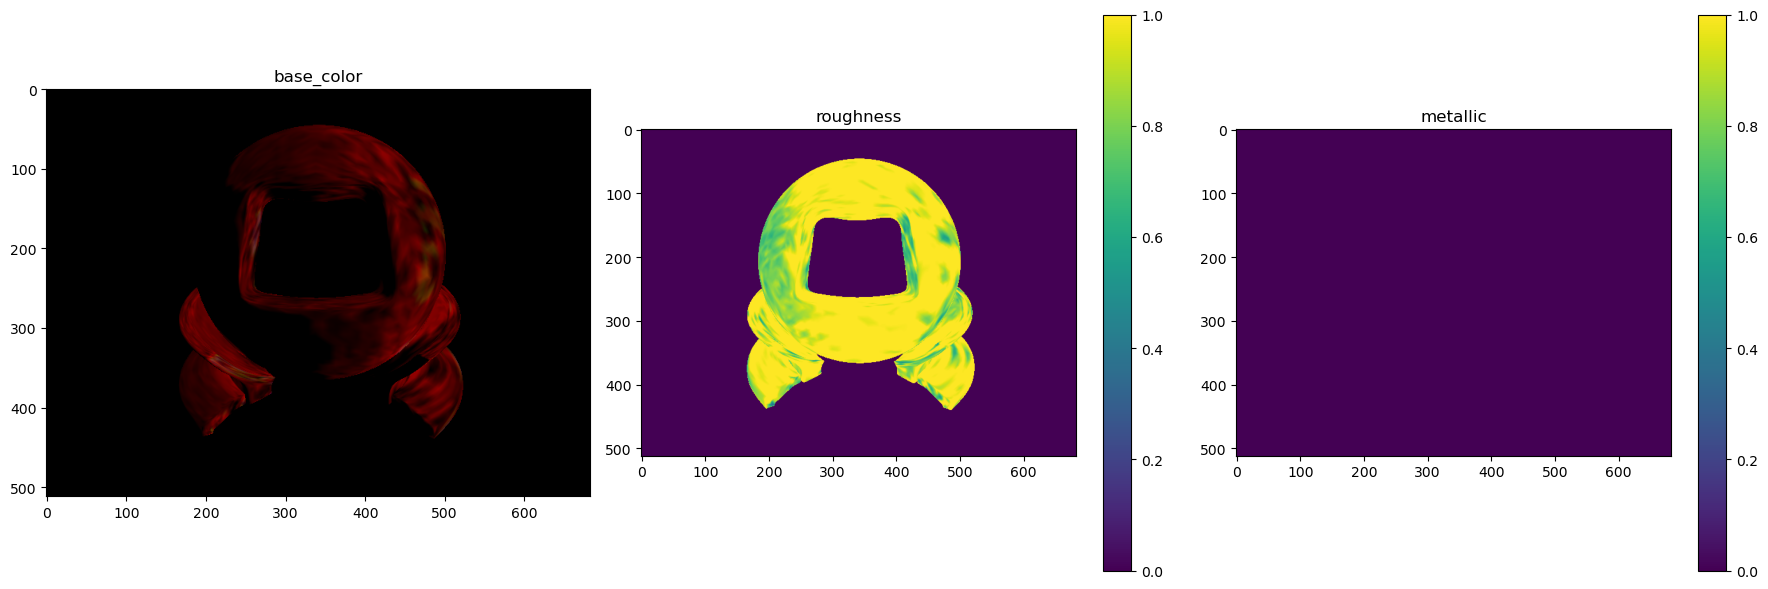

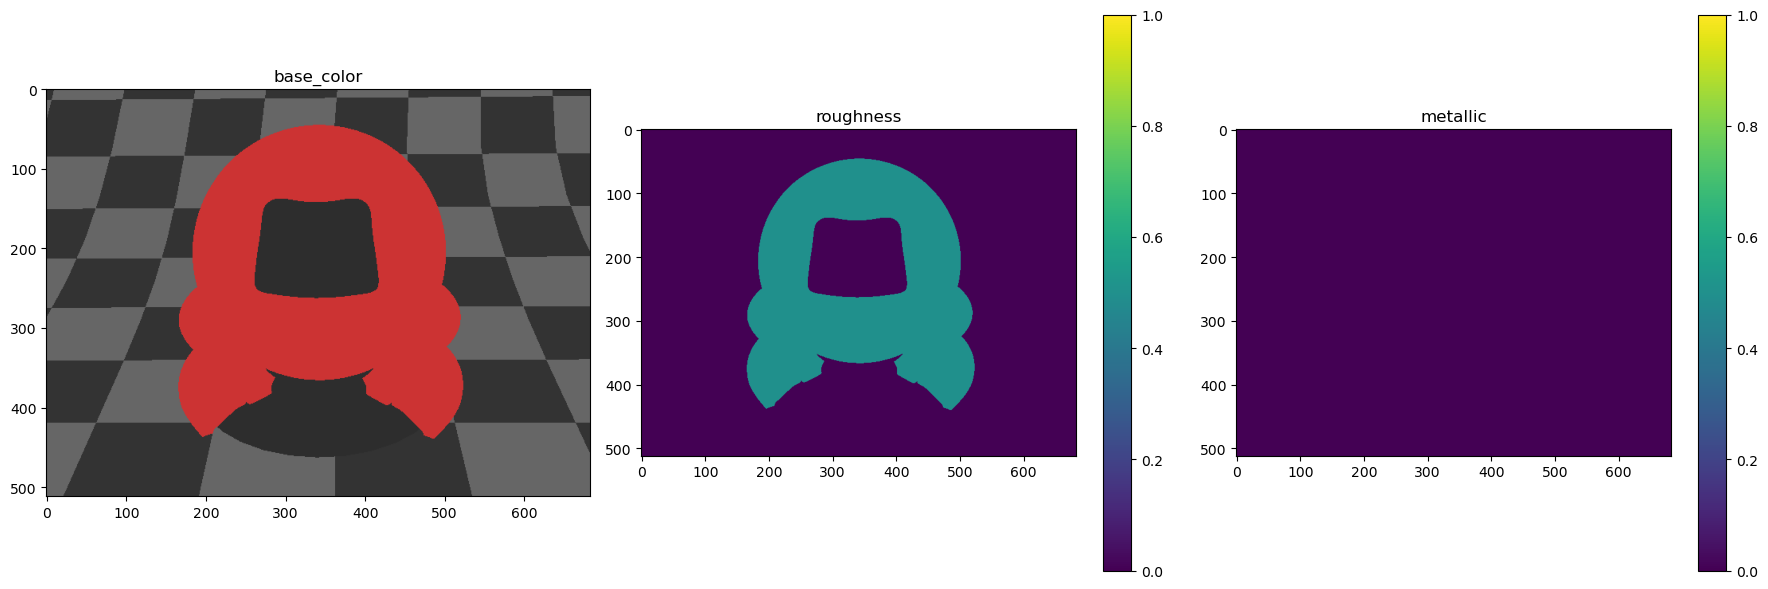

In [218]:
from scripts.radiosity.bsdf_utils import render_attributes, render_attributes_gt

out = render_attributes(scene, None, True, fp + "final")
# BSDF final values
plt.figure(figsize=(18,6), dpi=100)
plt.subplot(131); plt.imshow(out[:,:,:3]); plt.title("base_color")
plt.subplot(132); plt.imshow(out[:,:,3], vmin=0.0, vmax=1.0); plt.title("roughness"); plt.colorbar()
plt.subplot(133); plt.imshow(out[:,:,4], vmin=0.0, vmax=1.0); plt.title("metallic");  plt.colorbar()
# plt.subplot(133); plt.imshow(out[:,:,5], vmin=0.0, vmax=1.0); plt.title("anisotropic");  plt.colorbar()
# plt.subplot(133); plt.imshow(out[:,:,6], vmin=0.0, vmax=1.0); plt.title("spec_tint");  plt.colorbar()
plt.tight_layout()
plt.gcf().savefig(fp + "final.png")

out_gt = render_attributes_gt(scene, None, True, fp + "reference")

# BSDF final values
plt.figure(figsize=(18,6), dpi=100)
plt.subplot(131); plt.imshow(out_gt[:,:,:3]); plt.title("base_color")
plt.subplot(132); plt.imshow(out_gt[:,:,3], vmin=0.0, vmax=1.0); plt.title("roughness"); plt.colorbar()
plt.subplot(133); plt.imshow(out_gt[:,:,4], vmin=0.0, vmax=1.0); plt.title("metallic");  plt.colorbar()
# plt.subplot(133); plt.imshow(out_gt[:,:,5], vmin=0.0, vmax=1.0); plt.title("anisotropic");  plt.colorbar()
# plt.subplot(133); plt.imshow(out_gt[:,:,6], vmin=0.0, vmax=1.0); plt.title("spec_tint");  plt.colorbar()
plt.tight_layout()
plt.gcf().savefig(fp + "ref.png")


In [86]:
# from scripts.radiosity.bsdf_utils import ps_visualize_textures

# ps_visualize_textures(scene)